<a href="https://colab.research.google.com/github/szymonszwedzinskiii/DataTemplates/blob/main/LogisticRegresionVsDecisionTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Imports:

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from collections import Counter
from sklearn.metrics import ConfusionMatrixDisplay


Logistic regresion

In [6]:
df = pd.read_csv('/content/Crop_recommendation.csv')

In [3]:
X = df.iloc[:,:-1].values
y = df.iloc[:,-1].values
y = LabelEncoder().fit_transform(y)
X_train,X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
w = np.random.randn(X_train.shape[1], len(np.unique(y_train))) * 0.01
b = np.zeros(len(np.unique(y_train)))


In [33]:
def softmax(logits):
  return np.exp(logits) / np.sum(np.exp(logits), axis=0)

In [34]:
def softmax(logits):
    logits = np.atleast_2d(logits)  # gwarantuje 2D: (m, K)
    exp = np.exp(logits - np.max(logits, axis=1, keepdims=True))  # stabilizacja
    return exp / np.sum(exp, axis=1, keepdims=True)

In [35]:
def model(X,w,b):
  return softmax(np.dot(X,w) + b)

In [36]:
def compute_cost(X,y,w,b):
  m = X.shape[0]
  cost = 0
  pred = model(X,w,b)

  for i in range(m):
    cost += -np.log(pred[i,y[i]])
  return cost/m

In [37]:
pred = model(X_train,w,b)
print(pred)

[[5.06440827e-02 3.27760551e-01 7.97952158e-02 ... 2.72457321e-03
  2.35021916e-02 3.68459698e-02]
 [4.86901164e-02 6.01763350e-02 2.14698596e-01 ... 7.42228366e-03
  4.63175536e-02 1.90426897e-02]
 [8.07906493e-02 7.36991458e-02 1.66648638e-01 ... 1.60074654e-02
  3.78986752e-02 2.85584265e-02]
 ...
 [6.06865813e-02 1.60870463e-01 9.50805653e-02 ... 3.22881023e-03
  1.68580076e-02 2.71917779e-02]
 [8.78969144e-01 1.11851056e-02 1.02032408e-02 ... 1.95957862e-03
  5.28225893e-04 1.17101550e-03]
 [5.96329848e-02 5.16898765e-02 1.96583066e-01 ... 1.19100199e-02
  4.90482226e-02 2.09088186e-02]]


In [38]:
cost = compute_cost(X_train,y_train,w,b)

print(cost)

4.296585473062449


In [39]:
def gradient_descent(X,y,w,b,learning_rate,iterations):
  m = X.shape[0]
  for i in range(iterations):
    cost_history = []
    w_history = []
    b_history = []
    pred = model(X,w,b)
    cost = compute_cost(X,y,w,b)
    cost_history.append(cost)
    w_history.append(w)
    b_history.append(b)
    y_onehot = np.zeros_like(pred)
    y_onehot[np.arange(len(y)), y] = 1
    dw = (1/m) * np.dot(X.T,(pred - y_onehot))
    db = (1/m) * np.sum(pred - y_onehot)

    w -= learning_rate * dw
    b -= learning_rate * db
  return cost_history,w_history,b_history
cost_history, w_history, b_history = gradient_descent(X_train,y_train,w,b,0.01,1000)
y_pred_logreg = model(X_test,w_history[-1],b_history[-1])
y_pred_logreg = np.argmax(y_pred_logreg, axis=1)

cost = compute_cost(X_test,y_test,w_history[-1],b_history[-1])
print(f'Cost on training data = {cost_history[-1]} and cost on test data = {cost}')


Cost on training data = 0.4622858515175902 and cost on test data = 0.8191193781750854


Decission tree

In [20]:
df = pd.read_csv('/content/Crop_recommendation.csv')
X = df.iloc[:,:-1].values
y = df.iloc[:,-1].values
y = LabelEncoder().fit_transform(y)
X_train,X_test, y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
w = np.random.randn(X_train.shape[1], len(np.unique(y_train))) * 0.01
b = np.zeros(len(np.unique(y_train)))

In [21]:
def gini_index(groups, classes):
    total_instances = sum(len(group) for group in groups)
    gini = 0.0
    for group in groups:
        size = len(group)
        if size == 0:
            continue
        score = 0.0
        labels = [row[-1] for row in group]
        for c in classes:
            p = labels.count(c) / size
            score += p * p
        gini += (1.0 - score) * (size / total_instances)
    return gini

In [22]:
def test_split(index, value, dataset):
    left, right = [], []
    for row in dataset:
        if row[index] <= value:
            left.append(row)
        else:
            right.append(row)
    return left, right

In [23]:
def get_split(dataset):
    class_values = list(set(row[-1] for row in dataset))
    class_values = LabelEncoder().fit_transform(class_values)
    best_index, best_value, best_score, best_groups = None, None, float('inf'), None
    for index in range(len(dataset[0]) - 1):
        for row in dataset:
            groups = test_split(index, row[index], dataset)
            gini = gini_index(groups, class_values)
            if gini < best_score:
                best_index, best_value, best_score, best_groups = index, row[index], gini, groups
    return {"index": best_index, "value": best_value, "groups": best_groups}

In [24]:
def to_terminal(group):
    outcomes = [row[-1] for row in group]
    return Counter(outcomes).most_common(1)[0][0]


In [25]:
def split(node, max_depth, min_size, depth):
    left, right = node["groups"]
    del(node["groups"])

    if not left or not right:
        node["left"] = node["right"] = to_terminal(left + right)
        return

    if depth >= max_depth:
        node["left"], node["right"] = to_terminal(left), to_terminal(right)
        return

    if len(left) <= min_size:
        node["left"] = to_terminal(left)
    else:
        node["left"] = get_split(left)
        split(node["left"], max_depth, min_size, depth + 1)

    if len(right) <= min_size:
        node["right"] = to_terminal(right)
    else:
        node["right"] = get_split(right)
        split(node["right"], max_depth, min_size, depth + 1)


In [26]:
def build_tree(train, max_depth, min_size):
    root = get_split(train)
    split(root, max_depth, min_size, 1)
    return root

In [27]:
def predict(node, row):
    if row[node['index']] <= node['value']:
        if isinstance(node['left'], dict):
            return predict(node['left'], row)
        else:
            return node['left']
    else:
        if isinstance(node['right'], dict):
            return predict(node['right'], row)
        else:
            return node['right']

In [51]:
target = df.columns[-1]
df[target] = LabelEncoder().fit_transform(df[target])

dataset = df.values.tolist()
tree = build_tree(dataset[:1540], 5, 10)
correct =0
for row in df.values[1540:]:
    y_pred_tree = predict(tree, row[:-1])
    if row[-1] == y_pred_tree:
        correct += 1
accuracy = correct / len(df)
print(f'Accuracy: {round(accuracy,3)}%')


Accuracy: 0.027%


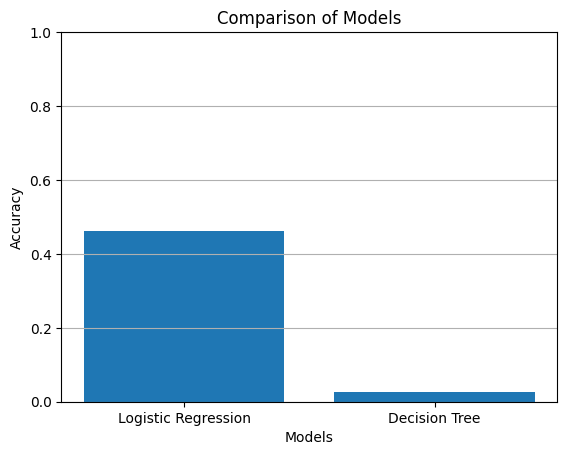

In [52]:
models = ['Logistic Regression', 'Decision Tree']
accuracies = [ cost_history[-1], accuracy]
plt.bar(models, accuracies)
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Comparison of Models')
plt.ylim(0,1)
plt.grid(axis='y')
plt.show()

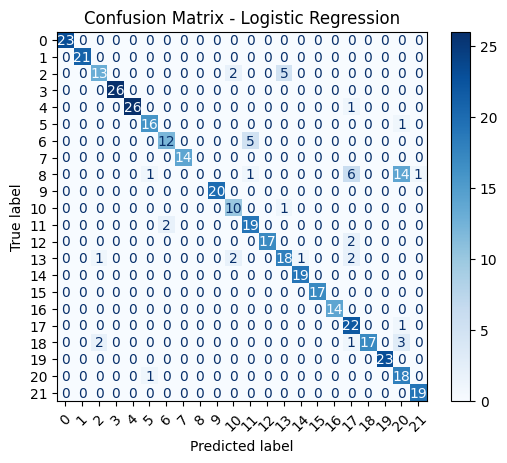

ValueError: Expected array-like (array or non-string sequence), got 20.0

In [53]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_logreg, cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

ConfusionMatrixDisplay.from_predictions(dataset, y_pred_tree, cmap='Greens', xticks_rotation=45)
plt.title('Confusion Matrix - Decision Tree')
plt.show()

In [ ]:
y_pred_logreg

array([15, 21, 17, 17,  0, 12,  0, 13, 14, 10,  2,  4, 19,  8,  4, 19,  0,
        6, 17, 15,  5, 17, 16, 17,  3,  8, 14, 16, 18, 20, 19, 13, 20, 10,
       20,  2,  8,  3,  3,  9, 17, 12,  2, 11, 14, 11, 18,  4, 15, 11,  2,
        5,  7, 14,  5,  9,  6,  0,  1, 10, 21,  4, 10, 16, 17,  2, 16, 20,
       15, 18, 15,  4, 20,  1,  2, 17,  1,  6, 21, 16,  5,  3, 20, 13, 16,
       12,  5, 13,  2, 19, 11, 13,  6, 17, 18, 13,  9,  5,  2, 10,  4, 20,
       16, 15, 21,  9, 21,  1, 18, 13,  1,  8,  6, 19, 18,  3, 11,  4, 19,
       20, 18,  7,  2,  4,  3, 13,  4, 11,  1, 13,  1,  9, 19,  3,  4, 16,
       18,  1,  1,  0,  9, 15, 14, 13,  4, 11,  0,  4,  9, 17, 14, 10, 21,
       14,  2,  2, 18,  9, 11,  8,  3,  0, 16,  6, 20,  4,  7, 10, 21,  7,
        7,  2, 19,  3,  4, 11, 10,  7, 21,  8,  5,  5,  9,  8, 13,  9,  1,
       18,  4, 17, 17, 14, 12, 19, 21,  9, 11,  0,  2,  3,  7,  7,  1,  6,
       20, 19, 14,  1, 20, 14, 11,  3,  3,  3,  0, 20,  9, 17,  5,  2,  9,
       12, 12,  4, 17,  0